# Практическая работа №3

по val выводить не надо

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

In [ ]:
data = pd.read_csv("../data/Data_for_UCI_named.csv")
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable


In [ ]:
stabf_dict = {
            "stable": 0,
            "unstable": 1}

data['stabf'] = data['stabf'].map(stabf_dict).astype("int32")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  int32  
dtypes: float64(13), int32(1)
memory usage: 1.0 MB


In [ ]:
X = data.drop("stab", axis=1)
# X = data.drop("p1", axis=1)
y = data["stab"]

x_train, x_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.4, random_state=1)

x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=1)

print(x_train.shape[0], x_val.shape[0], x_test.shape[0])

6000 2000 2000


In [ ]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    stats = {
        'R^2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }
        
    return stats

In [ ]:
lr0 = make_pipeline(StandardScaler(), LinearRegression())

lr0.fit(x_train, y_train)

y_train_pred = lr0.predict(x_train)
y_val_pred = lr0.predict(x_val)
y_test_pred = lr0.predict(x_test)


print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_val, y_val_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8179200386746116, 'MSE': 0.0002517173775306514, 'RMSE': 0.015865603598056124, 'MAE': 0.012618628779642363, 'MAPE': 2.695540114486368}
{'R^2': 0.8090354408986787, 'MSE': 0.00024732459391443146, 'RMSE': 0.01572655696312551, 'MAE': 0.012703751597076837, 'MAPE': 4.779034714804486}
{'R^2': 0.812484875196126, 'MSE': 0.0002570751690897415, 'RMSE': 0.0160335638299706, 'MAE': 0.012794568295759168, 'MAPE': 42.55806484600452}


In [ ]:
reg = make_pipeline(StandardScaler(), SGDRegressor(max_iter=1000, tol=1e-3))
reg.fit(x_train, y_train)

y_train_pred = reg.predict(x_train)
y_val_pred = reg.predict(x_val)
y_test_pred = reg.predict(x_test)


print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_val, y_val_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8172170950678098, 'MSE': 0.00025268916552955096, 'RMSE': 0.015896199719730216, 'MAE': 0.012615185807987744, 'MAPE': 2.7528183849881978}


{'R^2': 0.8087042082760567, 'MSE': 0.0002477535843735342, 'RMSE': 0.01574019009966316, 'MAE': 0.01267627725967052, 'MAPE': 5.251735746936936}
{'R^2': 0.8117449329387281, 'MSE': 0.0002580895980918615, 'RMSE': 0.016065167228879428, 'MAE': 0.012810738862467743, 'MAPE': 41.25004352007195}


In [ ]:
param_grid = {'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 2.0]}

In [ ]:
lasso = make_pipeline(StandardScaler(), GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2'))
lasso.fit(x_train, y_train)

y_train_pred = lasso.predict(x_train)
y_val_pred = lasso.predict(x_val)
y_test_pred = lasso.predict(x_test)

print(min(y_train_pred), min(y_train))
print(min(y_val_pred), min(y_val))
print(min(y_test_pred), min(y_test))


print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_val, y_val_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8178475680831732, 'MSE': 0.00025181756487192825, 'RMSE': 0.01586876065960818, 'MAE': 0.012635815042484396, 'MAPE': 2.7004575842188885}
{'R^2': 0.8091916608000885, 'MSE': 0.0002471222682899316, 'RMSE': 0.015720123036730076, 'MAE': 0.012706609355647904, 'MAPE': 4.8691389030745285}
{'R^2': 0.8125264667521904, 'MSE': 0.0002570181488556715, 'RMSE': 0.016031785579144687, 'MAE': 0.012796210100714198, 'MAPE': 43.018108893264234}


In [ ]:
ridge = make_pipeline(StandardScaler(), GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2'))
ridge.fit(x_train, y_train)

y_train_pred = ridge.predict(x_train)
y_val_pred = ridge.predict(x_val)
y_test_pred = ridge.predict(x_test)


print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_val, y_val_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.817920004817223, 'MSE': 0.0002517174243369722, 'RMSE': 0.015865605073143985, 'MAE': 0.01261874719639828, 'MAPE': 2.6949834736937373}
{'R^2': 0.8090409785163788, 'MSE': 0.0002473174219603508, 'RMSE': 0.01572632894099417, 'MAE': 0.012703626625961983, 'MAPE': 4.776933906631871}
{'R^2': 0.8124846438474707, 'MSE': 0.00025707548625879517, 'RMSE': 0.01603357372075219, 'MAE': 0.012794395637599525, 'MAPE': 42.55370153259393}


In [ ]:
elastic = make_pipeline(StandardScaler(), GridSearchCV(ElasticNet(), param_grid, cv=5, scoring='r2'))
elastic.fit(x_train, y_train)

y_train_pred = elastic.predict(x_train)
y_val_pred = elastic.predict(x_val)
y_test_pred = elastic.predict(x_test)


print(calculate_metrics(y_train, y_train_pred))
print(calculate_metrics(y_val, y_val_pred))
print(calculate_metrics(y_test, y_test_pred))

{'R^2': 0.8179011799923765, 'MSE': 0.0002517434488127482, 'RMSE': 0.015866425205847353, 'MAE': 0.012626508035102867, 'MAPE': 2.6978723299137646}
{'R^2': 0.809124749871231, 'MSE': 0.00024720892687404806, 'RMSE': 0.01572287908985018, 'MAE': 0.012704727098542513, 'MAPE': 4.82158015659963}
{'R^2': 0.8125237124166899, 'MSE': 0.0002570219249311496, 'RMSE': 0.01603190334711227, 'MAE': 0.012794505233231689, 'MAPE': 42.832753363196325}


In [ ]:
results = []
models = {
    "Linear Regression": lr0,
    "Ridge": ridge,
    "lasso": lasso,
    "ElasticNet": elastic,
    "SGDRegressor": reg
}

for model_name, model in models.items():
    train_metrics = calculate_metrics(y_train, model.predict(x_train))
    test_metrics = calculate_metrics(y_test, model.predict(x_test))
    
    results.append({
        'Регрессор': model_name,
        'Train': {
            'R^2': train_metrics['R^2'],
            'MSE': train_metrics['MSE'],
            'RMSE': train_metrics['RMSE'],
            'MAE': train_metrics['MAE'],
            'MAPE': train_metrics['MAPE']
        },
        'Test': {
            'R^2': test_metrics['R^2'],
            'MSE': test_metrics['MSE'],
            'RMSE': test_metrics['RMSE'],
            'MAE': test_metrics['MAE'],
            'MAPE': test_metrics['MAPE']
        }
    })

df_train = pd.DataFrame([r['Train'] for r in results])
df_test = pd.DataFrame([r['Test'] for r in results])

final_metrics = pd.concat({
    'Train Data': df_train,
    'Test Data': df_test
}, axis=1)

final_metrics.insert(0, 'Регрессор', [r['Регрессор'] for r in results])

final_metrics = final_metrics.style.format({
    ('Train Data', 'R^2'): '{:.2f}',
    ('Train Data', 'MSE'): '{:.4f}',
    ('Train Data', 'RMSE'): '{:.4f}',
    ('Train Data', 'MAE'): '{:.4f}',
    ('Train Data', 'MAPE'): '{:.4f}',
    ('Test Data', 'R^2'): '{:.2f}',
    ('Test Data', 'MSE'): '{:.4f}',
    ('Test Data', 'RMSE'): '{:.4f}',
    ('Test Data', 'MAE'): '{:.4f}',
    ('Test Data', 'MAPE'): '{:.4f}',
    
})

final_metrics


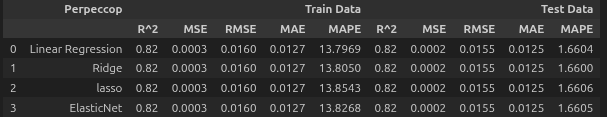

In [ ]:
x_train.to_csv('../data/trainR.csv', index=False)
x_val.to_csv('../data/valR.csv', index=False)
x_test.to_csv('../data/testR.csv', index=False)

# Выводы

Все модели регрессии показали практически одинаковое высокое качество предсказания. Значения R² находятся на уровне 0.81-0.82 как на обучающей, так и на тестовой выборках. MSE, RMSE и MAE также стабильны на всех выборках.

Другое разбиение (переход от 80-20 к 60-20-20) практически не повлияло на качество обучения и тестирования. Добавленные методы регуляризации (Ridge, Lasso, ElasticNet) также не дали значительного улучшения по сравнению с линейной регрессией. SGDRegressor продемонстрировал те же результаты, что и другие регрессоры.

Обнаружено странное поведение на test data — MAPE = 42.56. Это очень большое, нехарактерное значение. При этом все прочие метрики (MAE, RMSE, R²) имеют хорошие значения и демонстрируют устойчивость. Предположительно, это связано со случайным распределением в test data, не совсем удачным для этих данных. (В таблице не показано, но также были проверены значения MAPE для val data — они в рамках нормы)